# Amazon Kindle Publisher Analysis

Brief description of the dataset and where it came from.

## Questions
- Which genres generate the most daily revenue?
- Do big five publishers outperform indie publishers in ratings and sales?
- What is the relationship between sales rank and revenue?
- Which publisher types dominate which genres?

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load & Inspect Data

In [34]:
df = pd.read_csv('../data/publishers.csv')

df.head()

,genre,sold by,daily average.amazon revenue,daily average.author revenue,daily average.gross sales,daily average.publisher revenue,daily average.units sold,publisher.name,publisher.type,statistics.average rating,statistics.sale price,statistics.sales rank,statistics.total reviews
0,genre fiction,HarperCollins Publishers,6832.0,6832.0,34160.0,20496.0,7000,Katherine Tegen Books,big five,4.57,4.88,1,9604
1,genre fiction,HarperCollins Publishers,2487.5,2487.5,12437.5,7462.5,6250,HarperCollins e-books,big five,4.47,1.99,2,450
2,genre fiction,"Amazon Digital Services, Inc.",9559.0,9559.0,47795.0,28677.0,5500,(Small or Medium Publisher),small/medium,4.16,8.69,3,30
3,fiction,Hachette Book Group,8250.0,8250.0,41250.0,24750.0,5500,"Little, Brown and Company",big five,3.84,7.50,3,3747
4,genre fiction,Penguin Group (USA) LLC,7590.5,7590.5,37952.5,22771.5,4750,Dutton Children's,big five,4.75,7.99,4,9174


In [ ]:
# Check for missing values
print(df.isnull().sum())    

In [ ]:
print(df.describe())

In [ ]:
# Count unique values for relevant fields
print(df['genre'].nunique())
print(df['sold by'].nunique())
print(df['publisher.type'].nunique())



## 3. Data Cleaning

In [38]:
df.columns = df.columns.str.strip().str.lower().str.replace('.', '_').str.replace(' ', '_')


## 4. Exploratory Analysis

Text(0, 0.5, 'Average Daily Author Revenue')

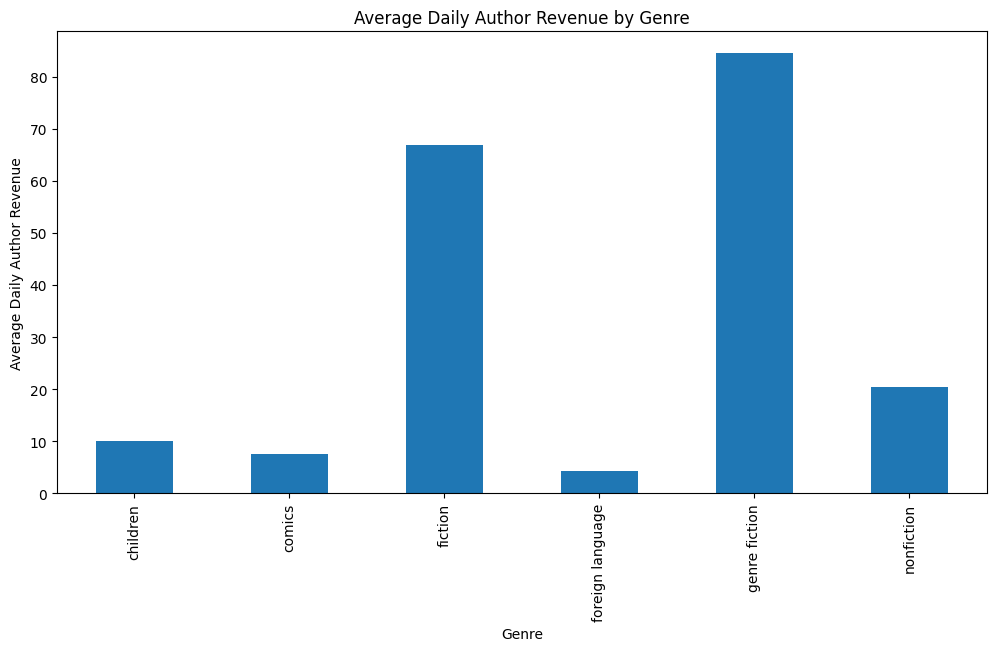

In [39]:
#4.1 Revenue by Genre

average_revenue_by_genre = df.groupby('genre')['daily_average_author_revenue'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
average_revenue_by_genre.plot(kind='bar', ax=ax)
ax.set_title('Average Daily Author Revenue by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Average Daily Author Revenue')

Text(0.5, 1.0, 'Daily Average Author Revenue: Big Five vs. Indie')

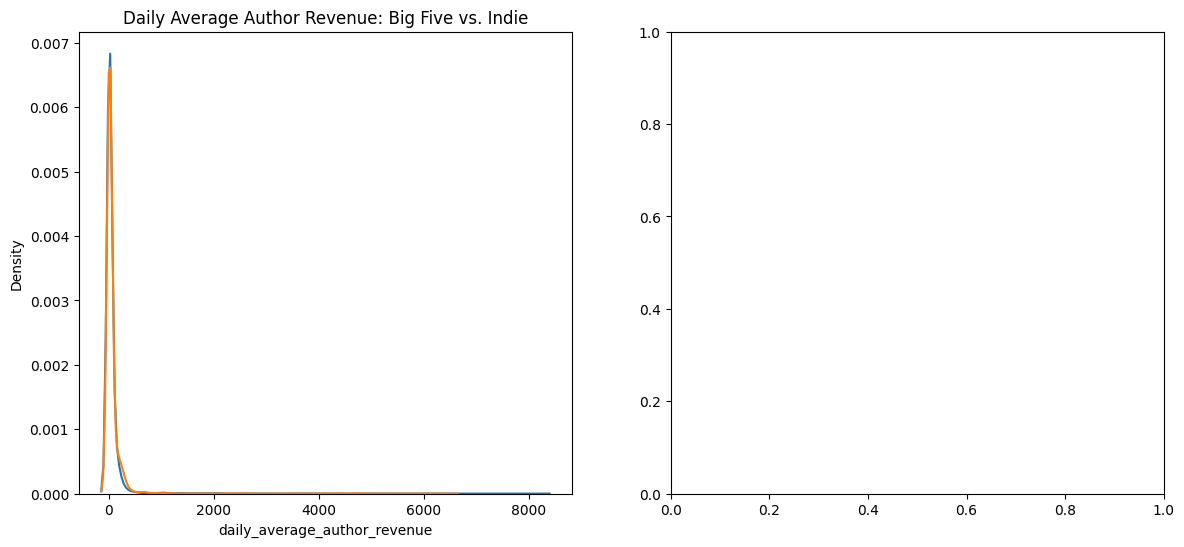

In [ ]:
# 4.2 Revenue and Ratings Big Publishers vs. Indie
# wanted to compare the average daily author revenue and average rating between big publishers and indie authors because big five has more volume

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

big_five = df[df['publisher_type'] == 'big five']
indie = df[df['publisher_type'] == 'indie']

sns.kdeplot(big_five['daily_average_author_revenue'], label='Big Five', ax=ax[0])
sns.kdeplot(indie['daily_average_author_revenue'], label='Indie', ax=ax[0])

ax[1].boxplot([big_five['statistics_average_rating'], indie['statistics_average_rating']], tick_labels=['Big Five', 'Indie'])
ax[1].set_title('Average Rating: Big Five vs. Indie')

## 5. Visualizations

## 6. Key Findings
